In [4]:
import cv2
import os
import numpy as np

def load_emotion_data(emotion, n):
    """
    Charge les n premières images d'une émotion spécifiée depuis un dossier.
    
    Args:
        emotion (str): Nom de l'émotion (nom du dossier).
        n (int): Nombre d'images à charger.
    
    Returns:
        tuple: Un tuple contenant un tableau numpy d'images et une liste des étiquettes.
    """
    # Chemin vers le dossier contenant les images
    folder_path = f"data/emotions/train/{emotion}"
    
    # Liste pour stocker les tableaux d'images et les étiquettes
    images = []
    labels = []
    
    # Compteur pour suivre le nombre d'images chargées
    count = 0
    
    # Parcourir le dossier et charger chaque image
    for filename in os.listdir(folder_path):
        # Vérifier si le fichier est une image (vous pouvez ajouter d'autres extensions d'images si nécessaire)
        if filename.endswith(".png") or filename.endswith(".jpg"):
            # Chemin complet du fichier
            file_path = os.path.join(folder_path, filename)
            # Charger l'image en tant que tableau de pixels
            image = cv2.imread(file_path)
            # Ajouter l'image à la liste
            images.append(image)
            labels.append(emotion)
            # Incrémenter le compteur
            count += 1
            # Vérifier si nous avons atteint le nombre d'images souhaité
            if count == n:
                break
    
    # Convertir la liste d'images en un tableau numpy
    images_array = np.array(images)
    
    # Afficher la forme de l'array numpy résultant
    print("Forme de l'array d'images :", images_array.shape)

    return images_array, labels

In [3]:
def load_data(n):
    (happy_data, happy_label) = load_emotion_data("happy",n)
    (neutral_data, neutral_label) = load_emotion_data("neutral",n)
    (sad_data, sad_label) = load_emotion_data("sad",n)
    X = np.concatenate((happy_data, neutral_data, sad_data), axis=0)
    y = np.concatenate((happy_label, neutral_label, sad_label), axis=0)
    
    # perm = np.random.permutation(len(X))
    # X = X[perm]
    # y = y[perm]

    return (X,y)

In [2]:
import matplotlib.pyplot as plt

def show_images(images_array, n):
    """
    Affiche les n premières images de images_array.
    
    Args:
        images_array (np.ndarray): Tableau numpy contenant les images.
        n (int): Nombre d'images à afficher.
    """
    # Vérifier que le nombre d'images demandé est inférieur ou égal au nombre total d'images
    n = min(n, len(images_array))
    
    # Créer une figure et des sous-plots pour afficher les images
    fig, axes = plt.subplots(1, n, figsize=(15, 15))
    
    # Afficher chaque image
    for i in range(n):
        # Lire l'image depuis le tableau d'images
        image = images_array[i]
        # Afficher l'image sur le subplot correspondant
        axes[i].imshow(image)
        axes[i].axis('off')  # Désactiver les axes
        
    plt.show()

In [4]:
X,y = load_data(4830)

Forme de l'array d'images : (4830, 48, 48, 3)
Forme de l'array d'images : (4830, 48, 48, 3)
Forme de l'array d'images : (4830, 48, 48, 3)


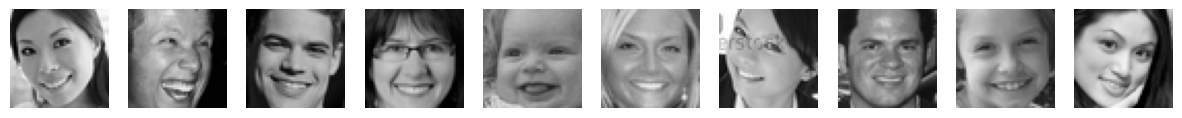

array(['happy', 'happy', 'happy', 'happy', 'happy', 'happy', 'happy',
       'happy', 'happy', 'happy'], dtype='<U7')

In [5]:
show_images(X,10)
y[:10]

In [5]:
import ctypes
import numpy as np
import numpy.ctypeslib
import random



rust_path = "my_lib/target/debug/deps/libmy_lib.so"

my_lib = ctypes.cdll.LoadLibrary(rust_path)


my_lib.create_MyMLP.argtypes = [ctypes.POINTER(ctypes.c_int32), ctypes.c_int32]
my_lib.create_MyMLP.restype = ctypes.c_void_p

my_lib.train_MyMLP.argtypes = [ctypes.c_void_p, 
                               
                               ctypes.POINTER(ctypes.c_double), 
                               ctypes.c_int32, 
                               
                               ctypes.POINTER(ctypes.c_double), 
                               ctypes.c_int32,
                               
                               ctypes.c_int32,
                               ctypes.c_double,
                               ctypes.c_int32,
                               ctypes.c_bool]
my_lib.train_MyMLP.restype = ctypes.POINTER(ctypes.c_double)

my_lib.predict_MyMLP.argtypes = [ctypes.c_void_p,
                                 ctypes.c_bool,
                                 ctypes.POINTER(ctypes.c_double),
                                 ctypes.c_int32,
                                 ctypes.c_int32]
my_lib.predict_MyMLP.restype = ctypes.POINTER(ctypes.c_double)

In [83]:
from sklearn.preprocessing import OneHotEncoder

# Load the data
X,y = load_data(1000)
n_samples = len(X)

# Réorganiser les données X et y selon la permutation
# perm = np.random.permutation(len(X))
# X = X[perm]
# y = y[perm]

nlp = np.array([6912, 768, 48, 3],np.int32)
c_nlp = np.ctypeslib.as_ctypes(nlp)
model = my_lib.create_MyMLP(c_nlp, len(nlp))


X_chunk = X.shape[1] * X.shape[2] * X.shape[3]
X_transformed = np.array(X, np.float64).flatten()/255

# Créer un encodeur OneHotEncoder
encoder = OneHotEncoder(sparse=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))
y_chunk = len(y_encoded[0])
y_encoded = y_encoded.flatten()

c_X = np.ctypeslib.as_ctypes(X_transformed)
c_y = np.ctypeslib.as_ctypes(y_encoded)

epochs = 10_00

p_losses = my_lib.train_MyMLP(model,
                    
                   c_X, 
                   X_chunk, 
                   
                   c_y,
                   y_chunk, 
                   
                   n_samples,
                   0.01,
                   epochs,
                   True)

p_predictions = my_lib.predict_MyMLP(model,
                     True,
                     c_X,
                     X_chunk,
                     n_samples)

test = np.ctypeslib.as_array(p_predictions, (y_chunk * n_samples,)).reshape(n_samples, y_chunk)
losses = np.ctypeslib.as_array(p_losses, (epochs,))

Forme de l'array d'images : (10, 48, 48, 3)
Forme de l'array d'images : (10, 48, 48, 3)
Forme de l'array d'images : (10, 48, 48, 3)


/home/bao/.local/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [86]:
pred = [np.argmax(sample) for sample in test]
print(pred)
print(y)

[0, 0, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0, 0, 0, 1, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0]
['happy' 'happy' 'happy' 'happy' 'happy' 'happy' 'happy' 'happy' 'happy'
 'happy' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral' 'neutral'
 'neutral' 'neutral' 'neutral' 'neutral' 'sad' 'sad' 'sad' 'sad' 'sad'
 'sad' 'sad' 'sad' 'sad' 'sad']


In [76]:
np.mean((y_encoded.reshape(n_samples, y_chunk) - test)**2)

0.022094438118276796

In [77]:
losses

array([0.51656016, 0.09540792, 0.34019429, ..., 0.01426827, 0.01221779,
       0.02740639])

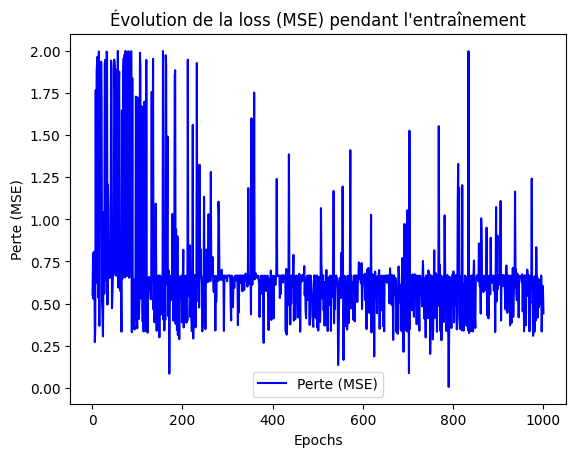

In [85]:
import matplotlib.pyplot as plt

# Création d'une liste d'époques pour l'axe des x
epochs = range(1, len(losses) + 1)

# Tracer les valeurs de perte en fonction des époques
plt.plot(epochs, losses, 'b', label='Perte (MSE)')
plt.title('Évolution de la loss (MSE) pendant l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Perte (MSE)')
plt.legend()
plt.show()
